In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

In [188]:
df = pd.read_csv("Supervised_Learning_Messy_Customer_Churn.csv")
df.shape

(184, 13)

In [189]:
df.head(5)

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55.0,NaN,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes


In [190]:
df.tail()

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
179,CUST-1107,55.0,54100.0,68.0,99.59,6.0,21.5,8.0,1 Year,Bank Transfer,East,Basic,Yes
180,CUST-1015,19.0,63000.0,NaN,64.24,1.0,13.0,7.0,Monthly,Credit Card,south,Premium,Yes
181,CUST-1093,29.0,45300.0,69.0,67.48,1.0,10.6,6.0,Monthly,Debit Card,East,Standard,No
182,CUST-1180,63.0,47100.0,45.0,65.58,0.0,11.3,1.0,Monthly,UPI,East,Standard,Yes
183,CUST-1103,NaN,48300.0,13.0,94.69,0.0,16.8,1.0,2 Year,Bank Transfer,West,Standard,No


In [191]:
df.columns

Index(['Customer_ID', 'Age', 'Annual_Income', 'Tenure_Months',
       'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB',
       'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region',
       'Plan_Type', 'Churn'],
      dtype='object')

In [192]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            184 non-null    object 
 1   Age                    176 non-null    float64
 2   Annual_Income          173 non-null    object 
 3   Tenure_Months          177 non-null    float64
 4   Monthly_Charges        178 non-null    float64
 5   Support_Calls_Last_3M  179 non-null    float64
 6   Data_Usage_GB          178 non-null    float64
 7   Satisfaction_Score     178 non-null    float64
 8   Contract_Type          184 non-null    object 
 9   Payment_Method         184 non-null    object 
 10  Region                 184 non-null    object 
 11  Plan_Type              184 non-null    object 
 12  Churn                  184 non-null    object 
dtypes: float64(6), object(7)
memory usage: 18.8+ KB


In [193]:
df['Annual_Income'] = pd.to_numeric(df['Annual_Income'], errors='coerce')

In [194]:
df['Annual_Income'].dtype

dtype('float64')

In [195]:
df.describe()

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
count,176.000000,1.720000e+02,177.000000,178.000000,179.000000,178.000000,178.000000
mean,36.164773,1.218552e+05,39.395480,80.205899,3.217877,17.806180,5.803371
std,12.865951,7.579821e+05,21.545185,74.179370,2.577455,9.245516,2.947869
min,-5.000000,-1.200000e+04,1.000000,0.000000,0.000000,-10.000000,1.000000
25%,29.000000,4.860000e+04,25.000000,57.885000,2.000000,11.600000,4.000000
50%,36.000000,6.440000e+04,38.000000,73.565000,3.000000,18.200000,6.000000
75%,41.000000,7.797500e+04,55.000000,90.280000,4.000000,24.200000,8.000000
max,145.000000,9.999999e+06,150.000000,999.000000,30.000000,44.000000,15.000000


In [196]:
df["Churn"].value_counts()

Churn
Yes    97
No     87
Name: count, dtype: int64

In [197]:
df["Customer_ID"].value_counts()

Customer_ID
CUST-1043    2
CUST-1110    2
CUST-1008    2
CUST-1152    2
CUST-1149    1
            ..
CUST-1107    1
CUST-1015    1
CUST-1093    1
CUST-1180    1
CUST-1103    1
Name: count, Length: 180, dtype: int64

In [198]:
df.isnull().sum()

Customer_ID               0
Age                       8
Annual_Income            12
Tenure_Months             7
Monthly_Charges           6
Support_Calls_Last_3M     5
Data_Usage_GB             6
Satisfaction_Score        6
Contract_Type             0
Payment_Method            0
Region                    0
Plan_Type                 0
Churn                     0
dtype: int64

In [199]:
df.isnull().sum().sum()

np.int64(50)

In [200]:
df.duplicated().sum()

np.int64(4)

In [201]:
df['Customer_ID'].duplicated().sum()

np.int64(4)

In [202]:
df[df.duplicated(keep=False)].sort_values('Customer_ID').head(10)

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
132,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
154,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
119,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
46,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
71,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
169,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No
176,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No


In [203]:
numeric_cols = ['Age','Annual_Income','Tenure_Months','Monthly_Charges',
                'Support_Calls_Last_3M','Data_Usage_GB','Satisfaction_Score']

In [204]:
num_cols = df.select_dtypes(exclude=['object']).columns
print(num_cols)

Index(['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges',
       'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score'],
      dtype='object')


In [205]:
object_cols = df.select_dtypes(include=['object']).columns
print(object_cols)

Index(['Customer_ID', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type',
       'Churn'],
      dtype='object')


In [206]:
df["Contract_Type"].value_counts()

Contract_Type
Monthly    104
1 Year      52
2 Year      23
MONTHLY      1
2-Year       1
1 year       1
monthly      1
?            1
Name: count, dtype: int64

In [207]:
df['Contract_Type'] = df['Contract_Type'].replace('?', pd.NA)

df['Contract_Type'] = (
    df['Contract_Type']
    .str.strip()
    .str.lower()
    .replace({
        'monthly': 'Monthly',
        '1 year': '1 Year',
        '2 year': '2 Year',
        '2-year': '2 Year'
    })
)

In [208]:
df["Contract_Type"].value_counts()

Contract_Type
Monthly    106
1 Year      53
2 Year      24
Name: count, dtype: int64

In [209]:
df['Contract_Type'] = df['Contract_Type'].fillna(df['Contract_Type'].mode()[0])

In [210]:
df["Payment_Method"].value_counts()

Payment_Method
Bank Transfer    48
UPI              46
Credit Card      43
Debit Card       42
?                 1
bank transfer     1
upi               1
Unknown           1
Credit card       1
Name: count, dtype: int64

In [211]:
df["Payment_Method"] = df["Payment_Method"].str.strip().str.title()
df["Payment_Method"].value_counts()

Payment_Method
Bank Transfer    49
Upi              47
Credit Card      44
Debit Card       42
?                 1
Unknown           1
Name: count, dtype: int64

In [212]:
df["Payment_Method"] = df["Payment_Method"].replace("?", np.nan)

In [213]:
df["Payment_Method"] = df["Payment_Method"].fillna(df["Payment_Method"].mode()[0])

In [214]:
df["Payment_Method"].value_counts()

Payment_Method
Bank Transfer    50
Upi              47
Credit Card      44
Debit Card       42
Unknown           1
Name: count, dtype: int64

In [215]:
df["Region"].value_counts()

Region
South     50
North     49
West      47
East      34
west       1
NORTH      1
?          1
south      1
Name: count, dtype: int64

In [216]:
df["Region"] = df["Region"].str.strip().str.title()
df["Region"].value_counts()

Region
South    51
North    50
West     48
East     34
?         1
Name: count, dtype: int64

In [217]:
df["Region"] = df["Region"].replace("?", np.nan)

In [218]:
df["Region"] = df["Region"].fillna(df["Region"].mode()[0])

In [219]:
df["Region"].value_counts()

Region
South    52
North    50
West     48
East     34
Name: count, dtype: int64

In [220]:
df["Plan_Type"].value_counts()

Plan_Type
Standard     93
Basic        48
Premium      40
basic         1
premium       1
STANDARD      1
Name: count, dtype: int64

In [221]:
df["Plan_Type"] = df["Plan_Type"].str.strip().str.title()
df["Plan_Type"].value_counts()

Plan_Type
Standard    94
Basic       49
Premium     41
Name: count, dtype: int64

In [ ]:
negative_count = (df.select_dtypes(include='number') < 0).sum()
print(negative_count)

Age                      1
Annual_Income            2
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            7
Satisfaction_Score       0
dtype: int64


In [223]:
numeric_cols = df.select_dtypes(include="number")
negative_rows = df[(numeric_cols < 0).any(axis=1)]
negative_rows

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
6,CUST-1025,31.0,88000.0,37.0,88.42,4.0,-2.1,9.0,1 Year,Debit Card,South,Standard,No
45,CUST-1105,34.0,35800.0,60.0,118.63,3.0,-0.8,7.0,2 Year,Upi,East,Standard,No
63,CUST-1079,NaN,53100.0,29.0,83.71,3.0,-1.6,5.0,Monthly,Upi,North,Basic,Yes
77,CUST-1033,36.0,57800.0,72.0,50.61,3.0,-1.1,1.0,Monthly,Credit Card,North,Standard,Yes
95,CUST-1143,20.0,-11500.0,2.0,57.34,NaN,19.4,2.0,1 Year,Credit Card,West,Standard,No
112,CUST-1062,34.0,-12000.0,29.0,60.69,4.0,18.9,4.0,Monthly,Upi,East,Basic,Yes
120,CUST-1124,22.0,50100.0,57.0,93.56,3.0,-0.3,9.0,Monthly,Upi,South,Standard,No
144,CUST-1018,-5.0,75900.0,64.0,137.15,5.0,14.2,5.0,Monthly,Upi,North,Premium,Yes
177,CUST-1021,51.0,100400.0,14.0,51.52,2.0,-2.0,1.0,2 Year,Upi,South,Premium,No
178,CUST-1072,51.0,NaN,38.0,77.19,5.0,-10.0,5.0,Monthly,Credit Card,West,Standard,No


In [224]:
df["Age"] = df["Age"].mask(df["Age"] < 0, np.nan)
df["Data_Usage_GB"] = df["Data_Usage_GB"].mask(
    df["Data_Usage_GB"] < 0, np.nan
)

In [225]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Data_Usage_GB"] = df["Data_Usage_GB"].fillna(
    df["Data_Usage_GB"].median()
)

In [ ]:
negative_count = (df.select_dtypes(include='number') < 0).sum()
print(negative_count)

Age                      0
Annual_Income            2
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
dtype: int64


In [227]:
median_income = df.loc[df['Annual_Income'] >= 0, 'Annual_Income'].median()


df.loc[df['Annual_Income'] < 0, 'Annual_Income'] = median_income

print("Negative values:", (df['Annual_Income'] < 0).sum())
print("Median used:", median_income)

Negative values: 0
Median used: 64700.0


In [228]:
numeric_df = df.select_dtypes(include="number")
correlation = numeric_df.corr()
correlation

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Age,1.000000,0.005074,0.032331,0.005018,-0.021513,-0.029712,-0.051955
Annual_Income,0.005074,1.000000,-0.127055,0.011238,0.025034,-0.120125,0.087546
Tenure_Months,0.032331,-0.127055,1.000000,-0.006854,-0.040394,0.034958,0.005583
Monthly_Charges,0.005018,0.011238,-0.006854,1.000000,0.021635,0.001403,0.105330
Support_Calls_Last_3M,-0.021513,0.025034,-0.040394,0.021635,1.000000,-0.036642,-0.031787
Data_Usage_GB,-0.029712,-0.120125,0.034958,0.001403,-0.036642,1.000000,0.042551
Satisfaction_Score,-0.051955,0.087546,0.005583,0.105330,-0.031787,0.042551,1.000000


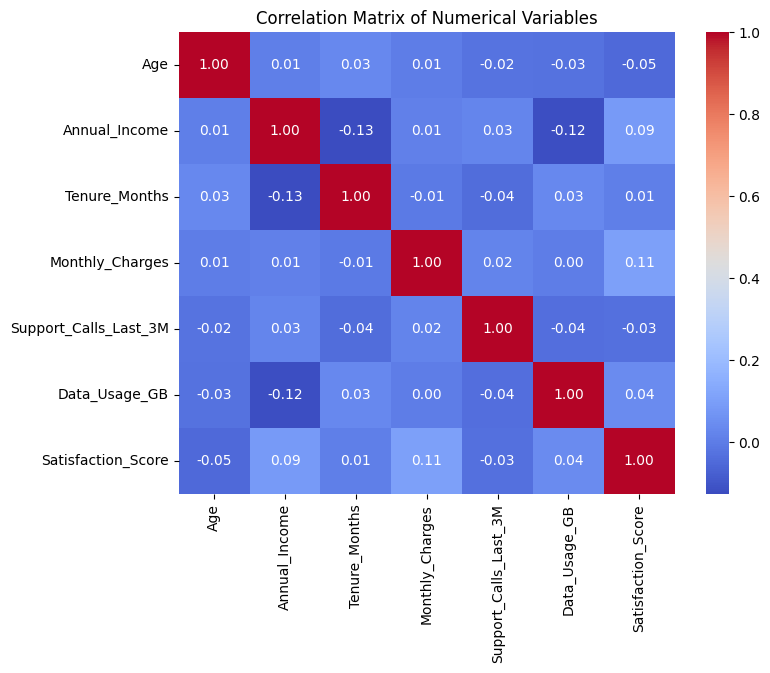

In [229]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [230]:
numeric_cols = df.select_dtypes(include="number")

for col in numeric_cols.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n{col}")
    print(f"Lower limit: {lower}")
    print(f"Upper limit: {upper}")
    print(f"Number of outliers: {len(outliers)}")


Age
Lower limit: 13.5
Upper limit: 57.5
Number of outliers: 5

Annual_Income
Lower limit: 6912.5
Upper limit: 120612.5
Number of outliers: 2

Tenure_Months
Lower limit: -20.0
Upper limit: 100.0
Number of outliers: 1

Monthly_Charges
Lower limit: 9.292500000000011
Upper limit: 138.8725
Number of outliers: 4

Support_Calls_Last_3M
Lower limit: -1.0
Upper limit: 7.0
Number of outliers: 1

Data_Usage_GB
Lower limit: -3.3125000000000036
Upper limit: 40.587500000000006
Number of outliers: 2

Satisfaction_Score
Lower limit: -2.0
Upper limit: 14.0
Number of outliers: 1


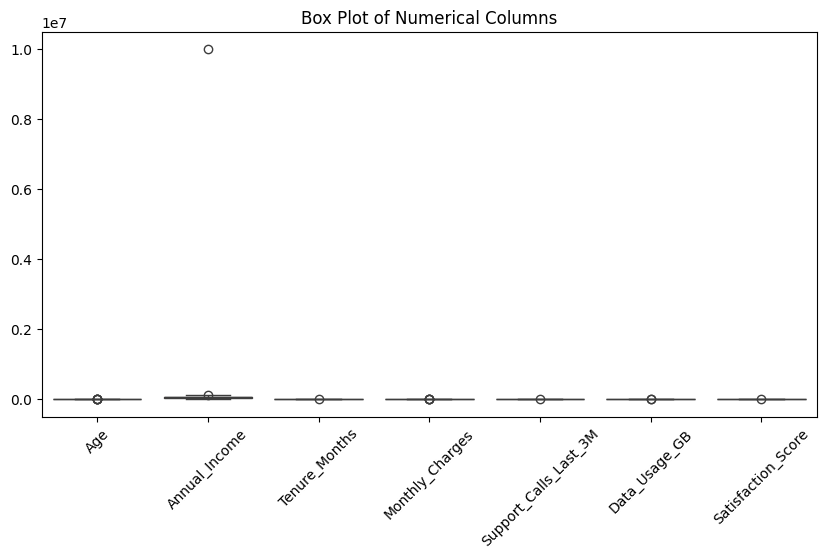

In [231]:
numeric_cols = df.select_dtypes(include="number")

plt.figure(figsize=(10, 5))

sns.boxplot(data=numeric_cols)

plt.xticks(rotation=45)
plt.title("Box Plot of Numerical Columns")
plt.show()

In [232]:
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()

    percentage = (outlier_count / len(df)) * 100

    print(f"{col}: {outlier_count} outliers ({percentage:.2f}%)")

Age: 5 outliers (2.72%)
Annual_Income: 2 outliers (1.09%)
Tenure_Months: 1 outliers (0.54%)
Monthly_Charges: 4 outliers (2.17%)
Support_Calls_Last_3M: 1 outliers (0.54%)
Data_Usage_GB: 2 outliers (1.09%)
Satisfaction_Score: 1 outliers (0.54%)


In [233]:
numeric_cols = df.select_dtypes(include="number").columns

total_outliers = 0

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    total_outliers += ((df[col] < lower) | (df[col] > upper)).sum()

print("Total outliers:", total_outliers)

Total outliers: 16


In [234]:
total_values = len(df) * len(numeric_cols)

percentage = (total_outliers / total_values) * 100

print(f"Total outliers: {total_outliers}")
print(f"Outlier percentage: {percentage:.2f}%")

Total outliers: 16
Outlier percentage: 1.24%


In [235]:

numeric_columns = [
    'Age',
    'Annual_Income',
    'Tenure_Months',
    'Monthly_Charges',
    'Support_Calls_Last_3M',
    'Data_Usage_GB',
    'Satisfaction_Score'
]

# Replace invalid values with NaN
df['Age'] = df['Age'].replace([10, 16, 17, 145], pd.NA)

df['Annual_Income'] = df['Annual_Income'].replace([9999999], pd.NA)

df['Tenure_Months'] = df['Tenure_Months'].replace([150], pd.NA)

df['Monthly_Charges'] = df['Monthly_Charges'].replace([0, 999], pd.NA)

df['Support_Calls_Last_3M'] = df['Support_Calls_Last_3M'].replace([30], pd.NA)

df['Satisfaction_Score'] = df['Satisfaction_Score'].replace([15], pd.NA)

# Convert to numeric
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Replace invalid/missing values with column median
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Fix capitalization
if 'Payment_Method' in df.columns:
    df['Payment_Method'] = df['Payment_Method'].replace({
        'Upi': 'UPI'
    })

print(df.head())

  Customer_ID   Age  Annual_Income  Tenure_Months  Monthly_Charges  \
0   CUST-1020  22.0        23800.0           11.0            62.96   
1   CUST-1043  35.0        69400.0           17.0            75.63   
2   CUST-1157  55.0        64700.0           49.0            92.85   
3   CUST-1112  36.0        80000.0            9.0            85.67   
4   CUST-1149  41.0        95700.0           51.0            60.77   

   Support_Calls_Last_3M  Data_Usage_GB  Satisfaction_Score Contract_Type  \
0                    7.0           20.4                 5.0       Monthly   
1                    6.0           17.5                 9.0       Monthly   
2                    3.0           21.6                 1.0       Monthly   
3                    0.0           34.3                 9.0       Monthly   
4                    1.0           23.7                 9.0       Monthly   

  Payment_Method Region Plan_Type Churn  
0  Bank Transfer  North  Standard   Yes  
1  Bank Transfer  South     Basi

In [236]:
import pandas as pd

numeric_columns = [
    'Age',
    'Annual_Income',
    'Tenure_Months',
    'Monthly_Charges',
    'Support_Calls_Last_3M',
    'Data_Usage_GB',
    'Satisfaction_Score'
]

total_outliers = 0
total_values = 0

for col in numeric_columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    
    outlier_count = len(outliers)
    
    total_outliers += outlier_count
    total_values += df[col].count()
    
    print(f"{col}: {outlier_count} outliers")


outlier_percentage = (total_outliers / total_values) * 100

print("\nTotal Outlier Values:", total_outliers)
print("Total Numerical Values:", total_values)
print(f"Overall Outlier Percentage: {outlier_percentage:.2f}%")

Age: 3 outliers
Annual_Income: 3 outliers
Tenure_Months: 0 outliers
Monthly_Charges: 8 outliers
Support_Calls_Last_3M: 0 outliers
Data_Usage_GB: 2 outliers
Satisfaction_Score: 0 outliers

Total Outlier Values: 16
Total Numerical Values: 1288
Overall Outlier Percentage: 1.24%


In [237]:
df.isnull().sum()

Customer_ID              0
Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
Contract_Type            0
Payment_Method           0
Region                   0
Plan_Type                0
Churn                    0
dtype: int64

In [238]:
df = df.drop_duplicates()

In [239]:
df.shape

(180, 13)

In [240]:
df.isnull().sum()

Customer_ID              0
Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
Contract_Type            0
Payment_Method           0
Region                   0
Plan_Type                0
Churn                    0
dtype: int64

In [241]:
numeric_cols = df.select_dtypes(include="number").columns

print(df[numeric_cols].median())

Age                         36.000
Annual_Income            64700.000
Tenure_Months               38.000
Monthly_Charges             73.565
Support_Calls_Last_3M        3.000
Data_Usage_GB               18.800
Satisfaction_Score           6.000
dtype: float64


In [242]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [243]:
print(df[numeric_cols].isnull().sum())
print(df[numeric_cols].dtypes)

Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
dtype: int64
Age                      float64
Annual_Income            float64
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
dtype: object


### Checking Again

In [244]:
import pandas as pd
import numpy as np

# ==========================================
# 1. BASIC DATASET INFORMATION
# ==========================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Rows and Columns:", df.shape)
print("\nData Types:")
print(df.dtypes)


# ==========================================
# 2. NULL VALUES
# ==========================================

print("\n" + "=" * 60)
print("NULL VALUES")
print("=" * 60)

null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]

if len(null_counts) == 0:
    print("No null values found.")
else:
    print(null_counts)
    print("\nTotal null values:", df.isnull().sum().sum())


# ==========================================
# 3. DUPLICATE DATA
# ==========================================

print("\n" + "=" * 60)
print("DUPLICATE DATA")
print("=" * 60)

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    print("\nDuplicate rows:")
    display(df[df.duplicated(keep=False)])

# ==========================================
# 5. INVALID / NON-NUMERIC DATA
# ==========================================

print("\n" + "=" * 60)
print("INVALID / NON-NUMERIC DATA")
print("=" * 60)

for col in numeric_cols:
    invalid = pd.to_numeric(df[col], errors='coerce').isna() & df[col].notna()
    
    if invalid.sum() > 0:
        print(f"\n{col}: {invalid.sum()} invalid values")
        print(df.loc[invalid, col].unique())

print("\nObject/Categorical columns:")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"{col}: {df[col].isna().sum()} null values")


# ==========================================
# 6. VALUE COUNT OF CATEGORICAL DATA
# ==========================================

print("\n" + "=" * 60)
print("CATEGORICAL VALUE COUNTS")
print("=" * 60)

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


# ==========================================
# 7. SUMMARY
# ==========================================

print("\n" + "=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)

print("Total Rows:", len(df))
print("Total Columns:", len(df.columns))
print("Total Null Values:", df.isnull().sum().sum())
print("Total Duplicate Rows:", df.duplicated().sum())
print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))

DATASET INFORMATION
Rows and Columns: (180, 13)

Data Types:
Customer_ID               object
Age                      float64
Annual_Income            float64
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
Contract_Type             object
Payment_Method            object
Region                    object
Plan_Type                 object
Churn                     object
dtype: object

NULL VALUES
No null values found.

DUPLICATE DATA
Duplicate rows: 0

INVALID / NON-NUMERIC DATA

Object/Categorical columns:
Customer_ID: 0 null values
Contract_Type: 0 null values
Payment_Method: 0 null values
Region: 0 null values
Plan_Type: 0 null values
Churn: 0 null values

CATEGORICAL VALUE COUNTS

--- Customer_ID ---
Customer_ID
CUST-1020    1
CUST-1043    1
CUST-1157    1
CUST-1112    1
CUST-1149    1
            ..
CUST-1107    1
CUST-1015    1
CUST-1093    1
CUST-1180    1
CUST-11

In [245]:
categorical_cols = df.select_dtypes(include='object').columns

print("Categorical Columns:", len(categorical_cols))
print(categorical_cols.tolist())

Categorical Columns: 6
['Customer_ID', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type', 'Churn']


In [246]:
cols = ['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']

for col in cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Contract_Type ---
Contract_Type
Monthly    104
1 Year      52
2 Year      24
Name: count, dtype: int64

--- Payment_Method ---
Payment_Method
Bank Transfer    47
UPI              47
Credit Card      44
Debit Card       41
Unknown           1
Name: count, dtype: int64

--- Region ---
Region
North    50
South    50
West     46
East     34
Name: count, dtype: int64

--- Plan_Type ---
Plan_Type
Standard    94
Basic       47
Premium     39
Name: count, dtype: int64


In [247]:
numeric_cols = df.select_dtypes(include=np.number).columns

negative_counts = {}

for col in numeric_cols:
    count = (df[col] < 0).sum()
    if count > 0:
        negative_counts[col] = count

if len(negative_counts) == 0:
    print("No negative values found.")
else:
    print("Negative values by column:")
    for col, count in negative_counts.items():
        print(f"{col}: {count}")

No negative values found.


In [248]:
clean_df = df.copy()

In [249]:
print(clean_df.shape)
print(clean_df.isnull().sum())
print(clean_df.duplicated().sum())

(180, 13)
Customer_ID              0
Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
Contract_Type            0
Payment_Method           0
Region                   0
Plan_Type                0
Churn                    0
dtype: int64
0


In [250]:
print((clean_df.select_dtypes(include='number') < 0).sum())

Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
dtype: int64


In [251]:
clean_df.to_csv('cleaned_customer.csv', index=False)

### Split X and Y

In [252]:
model_df = clean_df.copy()

model_df = model_df.drop(columns=['Customer_ID'])

X = model_df.drop(columns=['Churn'])
y = model_df['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (180, 11)
y shape: (180,)


In [253]:
X.head()

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type
0,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,Monthly,Bank Transfer,North,Standard
1,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic
2,55.0,64700.0,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic
3,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard
4,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium


In [1]:
y.head(10)

NameError: name 'y' is not defined

In [255]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [256]:
numeric_features

['Age',
 'Annual_Income',
 'Tenure_Months',
 'Monthly_Charges',
 'Support_Calls_Last_3M',
 'Data_Usage_GB',
 'Satisfaction_Score']

In [257]:
categorical_features

['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']

In [258]:
y = y.map({
    'No': 0,
    'Yes': 1
})

print(y.value_counts())

Churn
1    94
0    86
Name: count, dtype: int64


### Train & Test Split

In [259]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (144, 11)
X_test: (36, 11)
y_train: (144,)
y_test: (36,)


In [260]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [261]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

### Logistic

In [262]:
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [263]:
logistic_model.fit(X_train, y_train)
y_pred_logistic = logistic_model.predict(X_test)

In [264]:
accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression")
print("--------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Logistic Regression
--------------------
Accuracy : 0.5833333333333334
Precision: 0.625
Recall   : 0.5263157894736842
F1 Score : 0.5714285714285714


In [265]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.55      0.65      0.59        17
           1       0.62      0.53      0.57        19

    accuracy                           0.58        36
   macro avg       0.59      0.59      0.58        36
weighted avg       0.59      0.58      0.58        36



In [266]:
cm = confusion_matrix(y_test, y_pred_logistic)

print(cm)

[[11  6]
 [ 9 10]]


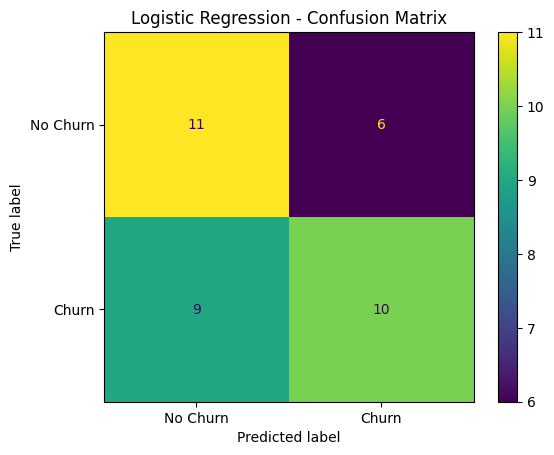

In [267]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn', 'Churn']
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [268]:
knn_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN")
print("--------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))

KNN
--------------------
Accuracy : 0.5
Precision: 0.5263157894736842
Recall   : 0.5263157894736842
F1 Score : 0.5263157894736842


In [269]:
decision_tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42
    ))
])

decision_tree_model.fit(X_train, y_train)

y_pred_dt = decision_tree_model.predict(X_test)

print("Decision Tree")
print("--------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

Decision Tree
--------------------
Accuracy : 0.4722222222222222
Precision: 0.5
Recall   : 0.3684210526315789
F1 Score : 0.42424242424242425


In [270]:
random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest")
print("--------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Random Forest
--------------------
Accuracy : 0.6111111111111112
Precision: 0.6666666666666666
Recall   : 0.5263157894736842
F1 Score : 0.5882352941176471


In [271]:
adaboost_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    ))
])

adaboost_model.fit(X_train, y_train)

y_pred_ada = adaboost_model.predict(X_test)

print("AdaBoost")
print("--------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_ada))
print("Precision:", precision_score(y_test, y_pred_ada))
print("Recall   :", recall_score(y_test, y_pred_ada))
print("F1 Score :", f1_score(y_test, y_pred_ada))

AdaBoost
--------------------
Accuracy : 0.5555555555555556
Precision: 0.6
Recall   : 0.47368421052631576
F1 Score : 0.5294117647058824


In [272]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boost_model = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('classifier', GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ))

])

gradient_boost_model.fit(X_train, y_train)

y_pred_gb = gradient_boost_model.predict(X_test)

print("Gradient Boosting")

print("--------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_gb))

print("Precision:", precision_score(y_test, y_pred_gb))

print("Recall   :", recall_score(y_test, y_pred_gb))

print("F1 Score :", f1_score(y_test, y_pred_gb))

Gradient Boosting
--------------------
Accuracy : 0.5277777777777778
Precision: 0.5625
Recall   : 0.47368421052631576
F1 Score : 0.5142857142857142


In [273]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [274]:
from catboost import CatBoostClassifier

In [275]:
catboost_model = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('classifier', CatBoostClassifier(
        iterations=100,
        random_seed=42,
        verbose=0
    ))

])

catboost_model.fit(X_train, y_train)

y_pred_cat = catboost_model.predict(X_test)

print("CatBoost")

print("--------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_cat))

print("Precision:", precision_score(y_test, y_pred_cat))

print("Recall   :", recall_score(y_test, y_pred_cat))

print("F1 Score :", f1_score(y_test, y_pred_cat))

CatBoost
--------------------
Accuracy : 0.5
Precision: 0.5294117647058824
Recall   : 0.47368421052631576
F1 Score : 0.5


In [276]:
models = {
    "Logistic Regression": logistic_model,
    "KNN": knn_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "AdaBoost": adaboost_model,
    "Gradient Boosting": gradient_boost_model,
   "CatBoost": catboost_model
}

In [277]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.583333,0.625000,0.526316,0.571429
1,KNN,0.500000,0.526316,0.526316,0.526316
2,Decision Tree,0.472222,0.500000,0.368421,0.424242
3,Random Forest,0.611111,0.666667,0.526316,0.588235
4,AdaBoost,0.555556,0.600000,0.473684,0.529412
5,Gradient Boosting,0.527778,0.562500,0.473684,0.514286
6,CatBoost,0.500000,0.529412,0.473684,0.500000


In [278]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [279]:
cv_scores = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='accuracy'
    )

    cv_scores.append({
        'Model': name,
        'CV Score': scores.mean()
    })

cv_df = pd.DataFrame(cv_scores)

cv_df

,Model,CV Score
0,Logistic Regression,0.589655
1,KNN,0.534236
2,Decision Tree,0.534729
3,Random Forest,0.575616
4,AdaBoost,0.610837
5,Gradient Boosting,0.465271
6,CatBoost,0.555419


In [280]:
final_comparison = results_df.merge(
    cv_df,
    on='Model'
)

final_comparison

,Model,Accuracy,Precision,Recall,F1,CV Score
0,Logistic Regression,0.583333,0.625000,0.526316,0.571429,0.589655
1,KNN,0.500000,0.526316,0.526316,0.526316,0.534236
2,Decision Tree,0.472222,0.500000,0.368421,0.424242,0.534729
3,Random Forest,0.611111,0.666667,0.526316,0.588235,0.575616
4,AdaBoost,0.555556,0.600000,0.473684,0.529412,0.610837
5,Gradient Boosting,0.527778,0.562500,0.473684,0.514286,0.465271
6,CatBoost,0.500000,0.529412,0.473684,0.500000,0.555419


In [281]:
pd.crosstab(
    df['Contract_Type'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Contract_Type,,
1 Year,53.846154,46.153846
2 Year,79.166667,20.833333
Monthly,37.500000,62.500000


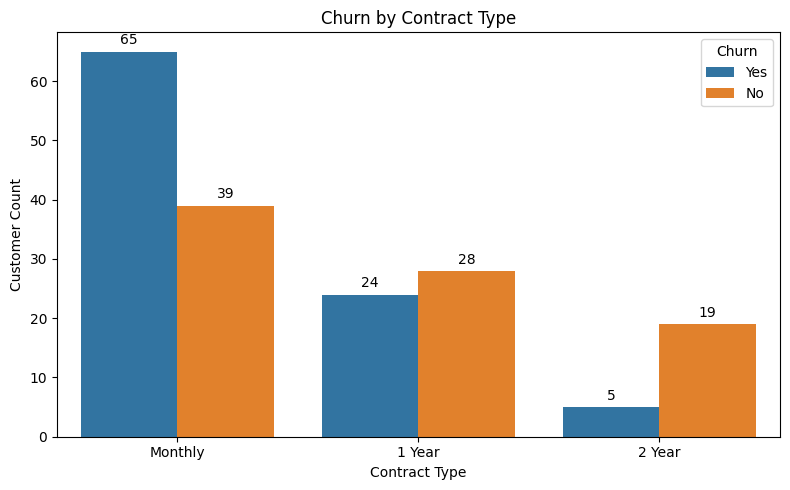

In [282]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x='Contract_Type',
    hue='Churn'
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")

# Show values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

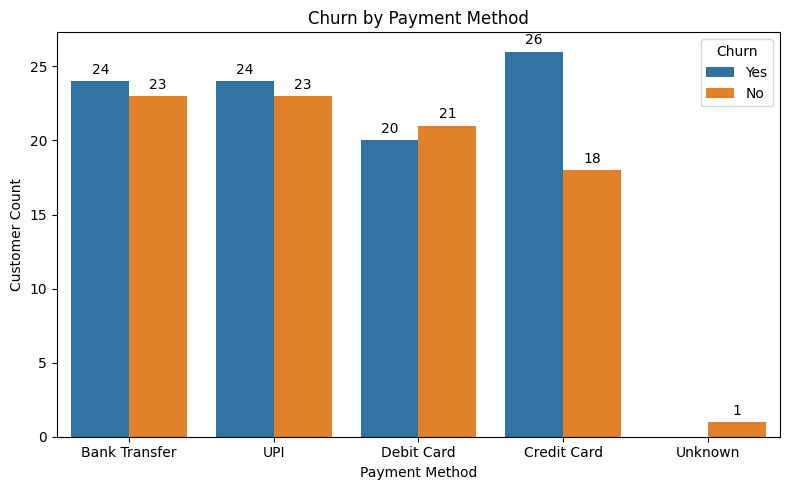

In [283]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x='Payment_Method',
    hue='Churn'
)

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Customer Count")

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

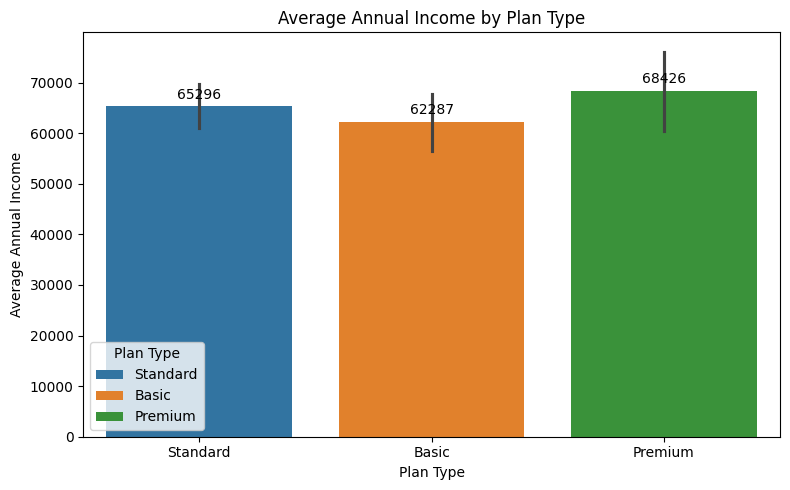

In [284]:

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df,
    x='Plan_Type',
    y='Annual_Income',
    estimator='mean',
    hue='Plan_Type',
    legend=True
)

plt.title("Average Annual Income by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Average Annual Income")
plt.legend(title="Plan Type")

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

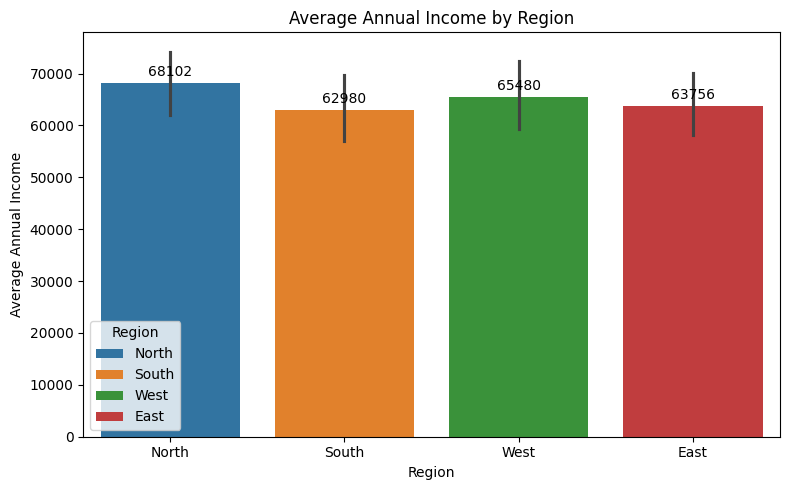

In [285]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df,
    x='Region',
    y='Annual_Income',
    estimator='mean',
    hue='Region',
    legend=True
)

plt.title("Average Annual Income by Region")
plt.xlabel("Region")
plt.ylabel("Average Annual Income")
plt.legend(title="Region")

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

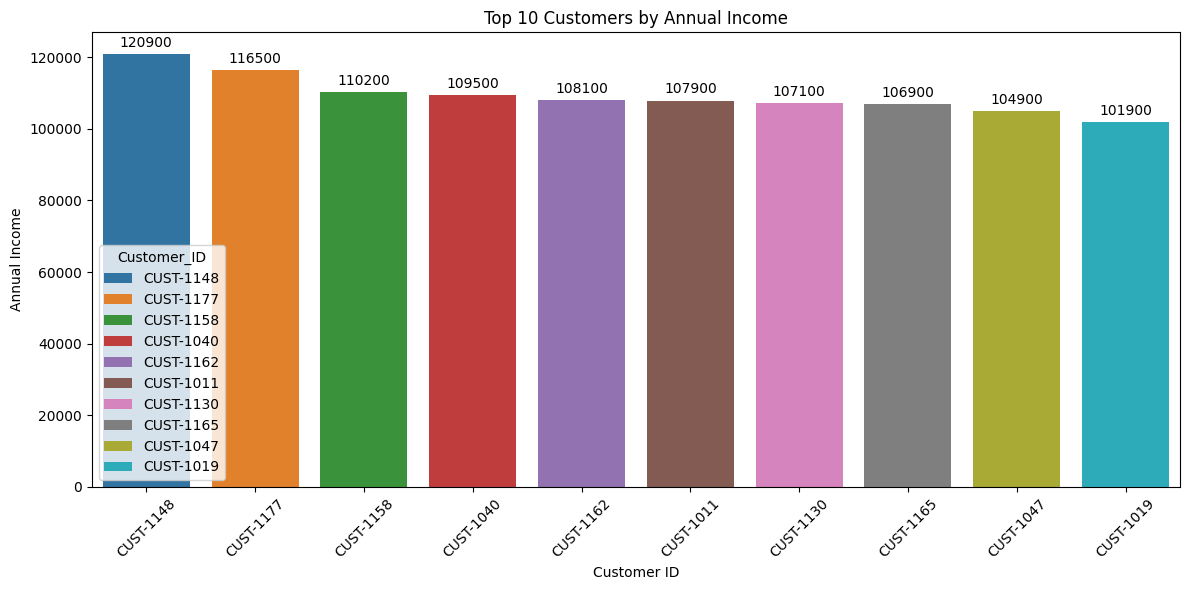

In [286]:
top_10 = df.nlargest(10, 'Annual_Income')

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=top_10,
    x='Customer_ID',
    y='Annual_Income',
    hue='Customer_ID',
    legend=True
)

plt.title("Top 10 Customers by Annual Income")
plt.xlabel("Customer ID")
plt.ylabel("Annual Income")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

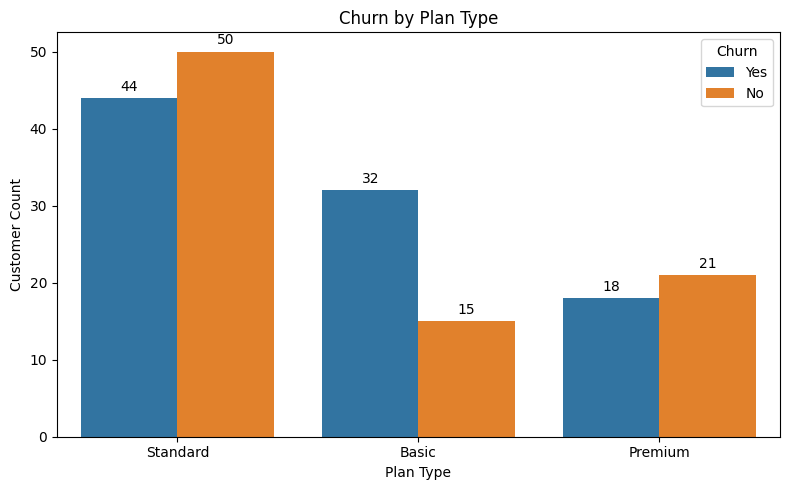

In [287]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x='Plan_Type',
    hue='Churn'
)

plt.title("Churn by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Customer Count")

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

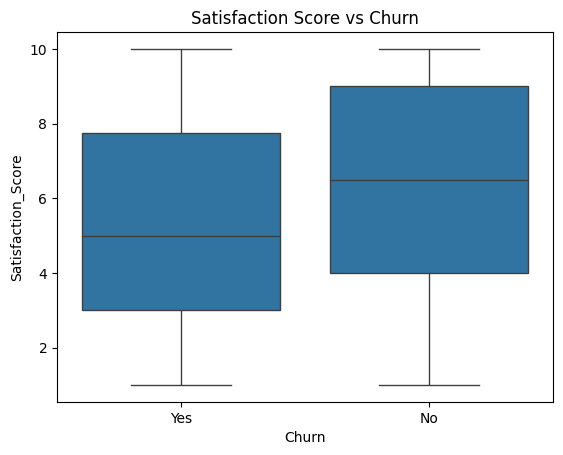

In [288]:
sns.boxplot(
    data=df,
    x='Churn',
    y='Satisfaction_Score'
)

plt.title("Satisfaction Score vs Churn")
plt.show()

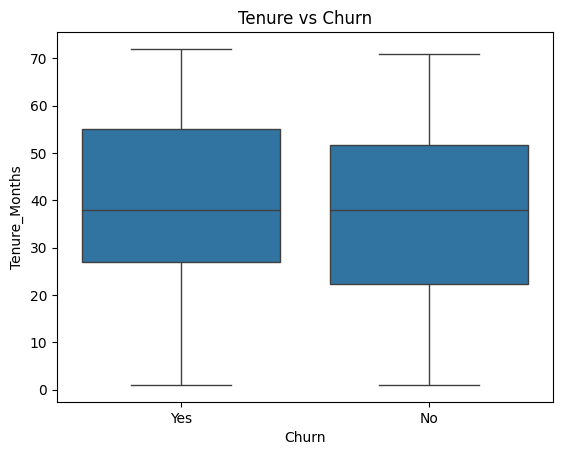

In [289]:
sns.boxplot(
    data=df,
    x='Churn',
    y='Tenure_Months'
)

plt.title("Tenure vs Churn")
plt.show()

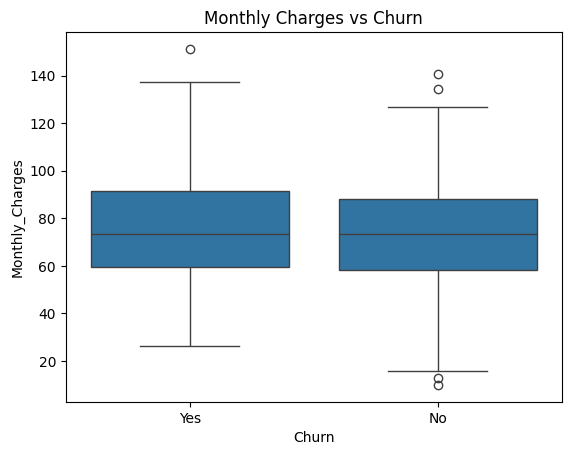

In [290]:
sns.boxplot(
    data=df,
    x='Churn',
    y='Monthly_Charges'
)

plt.title("Monthly Charges vs Churn")
plt.show()


Logistic Regression
[[11  6]
 [ 9 10]]


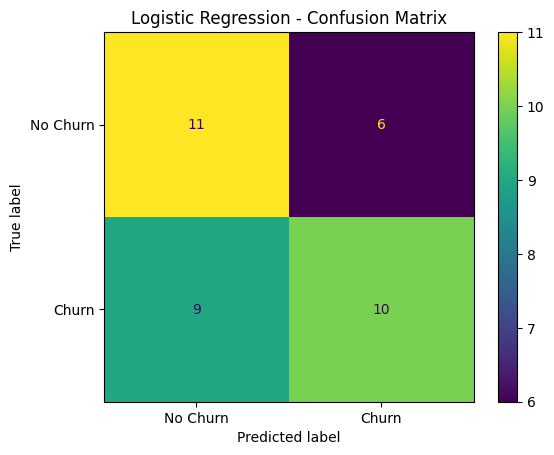


KNN
[[ 8  9]
 [ 9 10]]


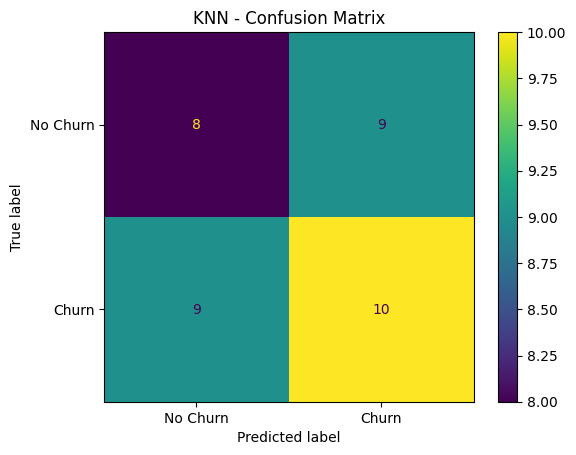


Decision Tree
[[10  7]
 [12  7]]


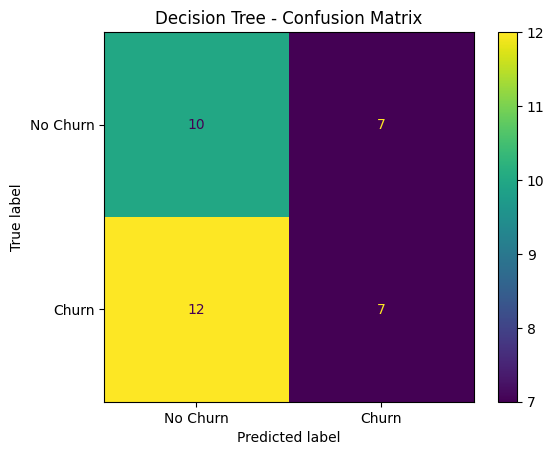


Random Forest
[[12  5]
 [ 9 10]]


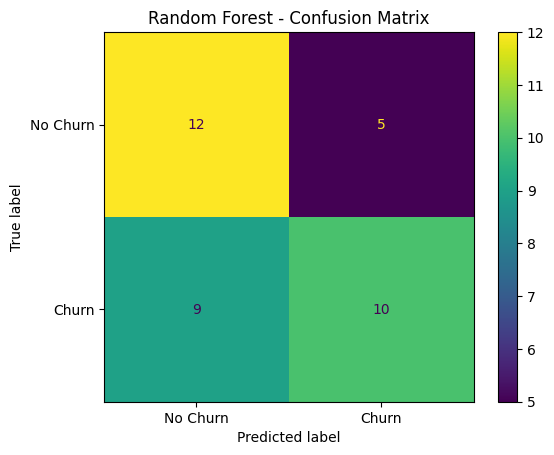


AdaBoost
[[11  6]
 [10  9]]


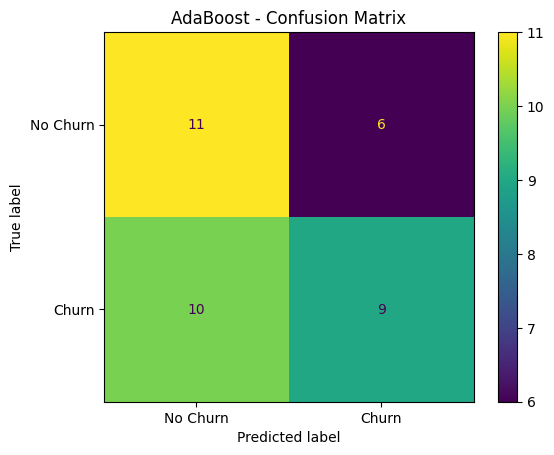

In [291]:
models_pred = {
    "Logistic Regression": y_pred_logistic,
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "AdaBoost": y_pred_ada
}

for name, y_pred in models_pred.items():

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name}")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    )

    disp.plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

In [292]:
for name, y_pred in models_pred.items():

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    print(f"\n{name}")
    print("True Negative :", tn)
    print("False Positive:", fp)
    print("False Negative:", fn)
    print("True Positive :", tp)


Logistic Regression
True Negative : 11
False Positive: 6
False Negative: 9
True Positive : 10

KNN
True Negative : 8
False Positive: 9
False Negative: 9
True Positive : 10

Decision Tree
True Negative : 10
False Positive: 7
False Negative: 12
True Positive : 7

Random Forest
True Negative : 12
False Positive: 5
False Negative: 9
True Positive : 10

AdaBoost
True Negative : 11
False Positive: 6
False Negative: 10
True Positive : 9


In [293]:
for name, model in models.items():

    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    print(
        f"{name}: "
        f"Train={train_score:.3f}, "
        f"Test={test_score:.3f}"
    )

Logistic Regression: Train=0.715, Test=0.583
KNN: Train=0.694, Test=0.500
Decision Tree: Train=1.000, Test=0.472
Random Forest: Train=1.000, Test=0.611
AdaBoost: Train=0.868, Test=0.556
Gradient Boosting: Train=1.000, Test=0.528
CatBoost: Train=1.000, Test=0.500


In [294]:
rf = random_forest_model.named_steps['classifier']

preprocessor_fitted = (
    random_forest_model
    .named_steps['preprocessor']
)

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    'Importance',
    ascending=False
)

importance_df.head(15)

,Feature,Importance
5,num__Data_Usage_GB,0.129697
2,num__Tenure_Months,0.124925
3,num__Monthly_Charges,0.115067
1,num__Annual_Income,0.107822
6,num__Satisfaction_Score,0.094890
0,num__Age,0.090898
4,num__Support_Calls_Last_3M,0.066069
8,cat__Contract_Type_2 Year,0.032525
9,cat__Contract_Type_Monthly,0.030968
19,cat__Plan_Type_Basic,0.019986


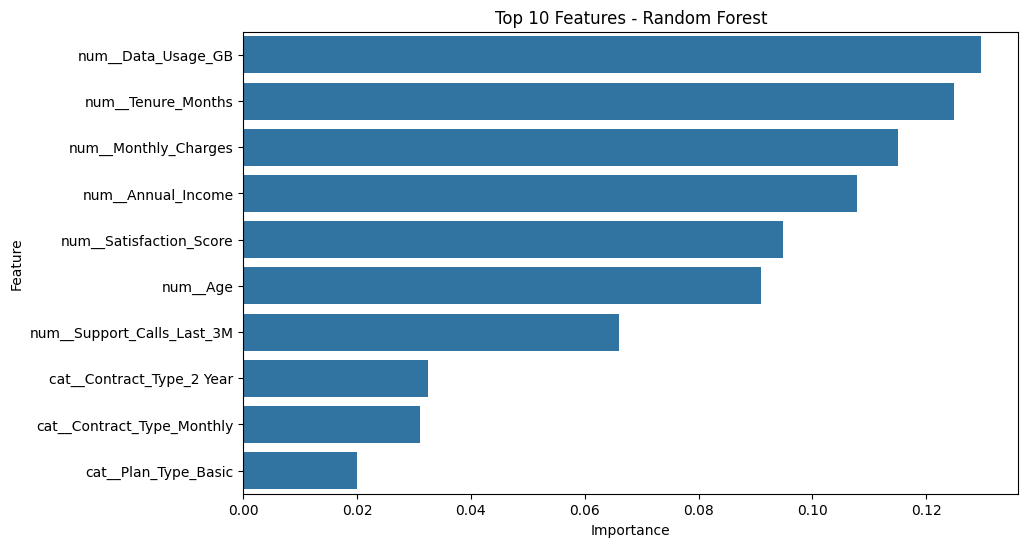

In [295]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Features - Random Forest")
plt.show()

In [296]:
from sklearn.preprocessing import MinMaxScaler

In [297]:
numeric_transformer_minmax = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='median')),

    ('scaler', MinMaxScaler())

])

categorical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('onehot', OneHotEncoder(handle_unknown='ignore'))

])

preprocessor_minmax = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_minmax, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [298]:
logistic_minmax = Pipeline(steps=[

    ('preprocessor', preprocessor_minmax),

    ('classifier', LogisticRegression(
        max_iter=1000
    ))

])

logistic_minmax.fit(X_train, y_train)

y_pred = logistic_minmax.predict(X_test)

print("Logistic Regression - MinMaxScaler")
print("--------------------")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Logistic Regression - MinMaxScaler
--------------------
Accuracy : 0.6111111111111112
Precision: 0.6666666666666666
Recall   : 0.5263157894736842
F1 Score : 0.5882352941176471


Logistic Regression - MinMaxScaler Confusion Matrix
-----------------------------------
[[12  5]
 [ 9 10]]


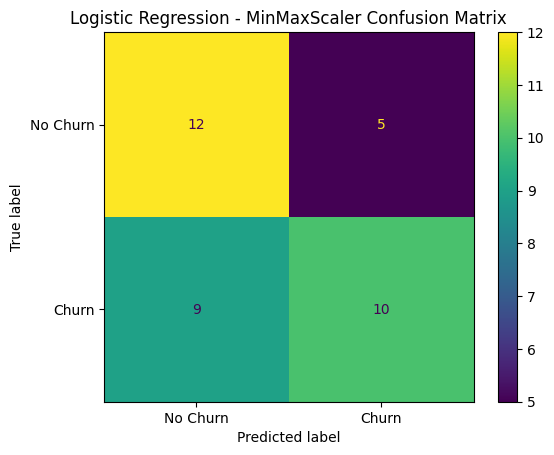

In [299]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Logistic Regression - MinMaxScaler Confusion Matrix")
print("-----------------------------------")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Logistic Regression - MinMaxScaler Confusion Matrix")
plt.show()

In [300]:
from sklearn.preprocessing import RobustScaler

In [301]:
numeric_transformer_robust = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='median')),

    ('scaler', RobustScaler())

])

preprocessor_robust = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_robust, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [302]:
logistic_robust = Pipeline(steps=[

    ('preprocessor', preprocessor_robust),

    ('classifier', LogisticRegression(
        max_iter=1000
    ))

])

logistic_robust.fit(X_train, y_train)

y_pred = logistic_robust.predict(X_test)

print("Logistic Regression - RobustScaler")
print("--------------------")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Logistic Regression - RobustScaler
--------------------
Accuracy : 0.5833333333333334
Precision: 0.625
Recall   : 0.5263157894736842
F1 Score : 0.5714285714285714


In [303]:
knn_minmax = Pipeline(steps=[

    ('preprocessor', preprocessor_minmax),

    ('classifier', KNeighborsClassifier(
        n_neighbors=5
    ))

])

knn_minmax.fit(X_train, y_train)

y_pred_knn_minmax = knn_minmax.predict(X_test)

print("KNN - MinMaxScaler")
print("--------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_knn_minmax))
print("Precision:", precision_score(y_test, y_pred_knn_minmax))
print("Recall   :", recall_score(y_test, y_pred_knn_minmax))
print("F1 Score :", f1_score(y_test, y_pred_knn_minmax))

KNN - MinMaxScaler
--------------------
Accuracy : 0.6388888888888888
Precision: 0.7142857142857143
Recall   : 0.5263157894736842
F1 Score : 0.6060606060606061


In [304]:
scaler_results = []

for name, y_pred in [
    ("KNN - StandardScaler", y_pred_knn),
    ("KNN - MinMaxScaler", y_pred_knn_minmax)
]:

    scaler_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

scaler_results_df = pd.DataFrame(scaler_results)

scaler_results_df

,Model,Accuracy,Precision,Recall,F1
0,KNN - StandardScaler,0.500000,0.526316,0.526316,0.526316
1,KNN - MinMaxScaler,0.638889,0.714286,0.526316,0.606061


In [305]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [306]:
knn_standard = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('classifier', KNeighborsClassifier(
        n_neighbors=5
    ))

])

In [307]:
knn_minmax = Pipeline(steps=[

    ('preprocessor', preprocessor_minmax),

    ('classifier', KNeighborsClassifier(
        n_neighbors=5
    ))

])

In [308]:
knn_robust = Pipeline(steps=[

    ('preprocessor', preprocessor_robust),

    ('classifier', KNeighborsClassifier(
        n_neighbors=5
    ))

])

In [309]:
knn_scalers = {
    "KNN - StandardScaler": knn_standard,
    "KNN - MinMaxScaler": knn_minmax,
    "KNN - RobustScaler": knn_robust
}

for name, model in knn_scalers.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='accuracy'
    )

    print("\n", name)
    print("CV Scores :", scores)
    print("CV Mean   :", scores.mean())
    print("CV Std    :", scores.std())


 KNN - StandardScaler
CV Scores : [0.62068966 0.31034483 0.62068966 0.65517241 0.46428571]
CV Mean   : 0.5342364532019704
CV Std    : 0.1300725833692743

 KNN - MinMaxScaler
CV Scores : [0.72413793 0.55172414 0.51724138 0.44827586 0.64285714]
CV Mean   : 0.5768472906403941
CV Std    : 0.09671244289109775

 KNN - RobustScaler
CV Scores : [0.65517241 0.51724138 0.48275862 0.55172414 0.5       ]
CV Mean   : 0.5413793103448276
CV Std    : 0.06129789253321094


In [310]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
cm_knn_minmax = confusion_matrix(
    y_test,
    y_pred_knn_minmax
)

print("KNN - MinMaxScaler Confusion Matrix")
print("-----------------------------------")
print(cm_knn_minmax)

KNN - MinMaxScaler Confusion Matrix
-----------------------------------
[[13  4]
 [ 9 10]]


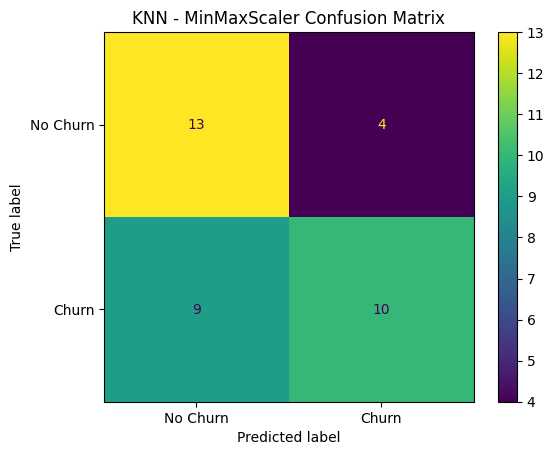

In [311]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn_minmax,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("KNN - MinMaxScaler Confusion Matrix")
plt.show()

In [312]:
tn, fp, fn, tp = cm_knn_minmax.ravel()

print("KNN - MinMaxScaler")
print("--------------------")
print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

KNN - MinMaxScaler
--------------------
True Negative : 13
False Positive: 4
False Negative: 9
True Positive : 10


In [313]:
models = {
    "KNN - MinMaxScaler": knn_minmax,
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "AdaBoost": adaboost_model,
    "Gradient Boosting": gradient_boost_model,
    "CatBoost": catboost_model
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='accuracy'
    )

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'CV Score': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy,Precision,Recall,F1,CV Score,CV Std
0,KNN - MinMaxScaler,0.638889,0.714286,0.526316,0.606061,0.576847,0.096712
1,Logistic Regression,0.583333,0.625000,0.526316,0.571429,0.589655,0.080427
2,Decision Tree,0.472222,0.500000,0.368421,0.424242,0.534729,0.093805
3,Random Forest,0.611111,0.666667,0.526316,0.588235,0.575616,0.106874
4,AdaBoost,0.555556,0.600000,0.473684,0.529412,0.610837,0.056939
5,Gradient Boosting,0.527778,0.562500,0.473684,0.514286,0.465271,0.070670
6,CatBoost,0.500000,0.529412,0.473684,0.500000,0.555419,0.067498


In [314]:
comparison_df.sort_values(
    by='F1',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,CV Score,CV Std
0,KNN - MinMaxScaler,0.638889,0.714286,0.526316,0.606061,0.576847,0.096712
3,Random Forest,0.611111,0.666667,0.526316,0.588235,0.575616,0.106874
1,Logistic Regression,0.583333,0.625000,0.526316,0.571429,0.589655,0.080427
4,AdaBoost,0.555556,0.600000,0.473684,0.529412,0.610837,0.056939
5,Gradient Boosting,0.527778,0.562500,0.473684,0.514286,0.465271,0.070670
6,CatBoost,0.500000,0.529412,0.473684,0.500000,0.555419,0.067498
2,Decision Tree,0.472222,0.500000,0.368421,0.424242,0.534729,0.093805


In [315]:
comparison_df.sort_values(
    by='Recall',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,CV Score,CV Std
0,KNN - MinMaxScaler,0.638889,0.714286,0.526316,0.606061,0.576847,0.096712
1,Logistic Regression,0.583333,0.625000,0.526316,0.571429,0.589655,0.080427
3,Random Forest,0.611111,0.666667,0.526316,0.588235,0.575616,0.106874
5,Gradient Boosting,0.527778,0.562500,0.473684,0.514286,0.465271,0.070670
4,AdaBoost,0.555556,0.600000,0.473684,0.529412,0.610837,0.056939
6,CatBoost,0.500000,0.529412,0.473684,0.500000,0.555419,0.067498
2,Decision Tree,0.472222,0.500000,0.368421,0.424242,0.534729,0.093805


In [316]:
comparison_df.sort_values(
    by='CV Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,CV Score,CV Std
4,AdaBoost,0.555556,0.600000,0.473684,0.529412,0.610837,0.056939
1,Logistic Regression,0.583333,0.625000,0.526316,0.571429,0.589655,0.080427
0,KNN - MinMaxScaler,0.638889,0.714286,0.526316,0.606061,0.576847,0.096712
3,Random Forest,0.611111,0.666667,0.526316,0.588235,0.575616,0.106874
6,CatBoost,0.500000,0.529412,0.473684,0.500000,0.555419,0.067498
2,Decision Tree,0.472222,0.500000,0.368421,0.424242,0.534729,0.093805
5,Gradient Boosting,0.527778,0.562500,0.473684,0.514286,0.465271,0.070670


In [317]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

perm_importance = permutation_importance(
    knn_minmax,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

                  Feature  Importance
7           Contract_Type    0.183333
10              Plan_Type    0.111111
6      Satisfaction_Score    0.030556
2           Tenure_Months    0.027778
9                  Region    0.025000
0                     Age    0.019444
8          Payment_Method    0.013889
1           Annual_Income    0.011111
3         Monthly_Charges    0.011111
4   Support_Calls_Last_3M   -0.005556
5           Data_Usage_GB   -0.013889


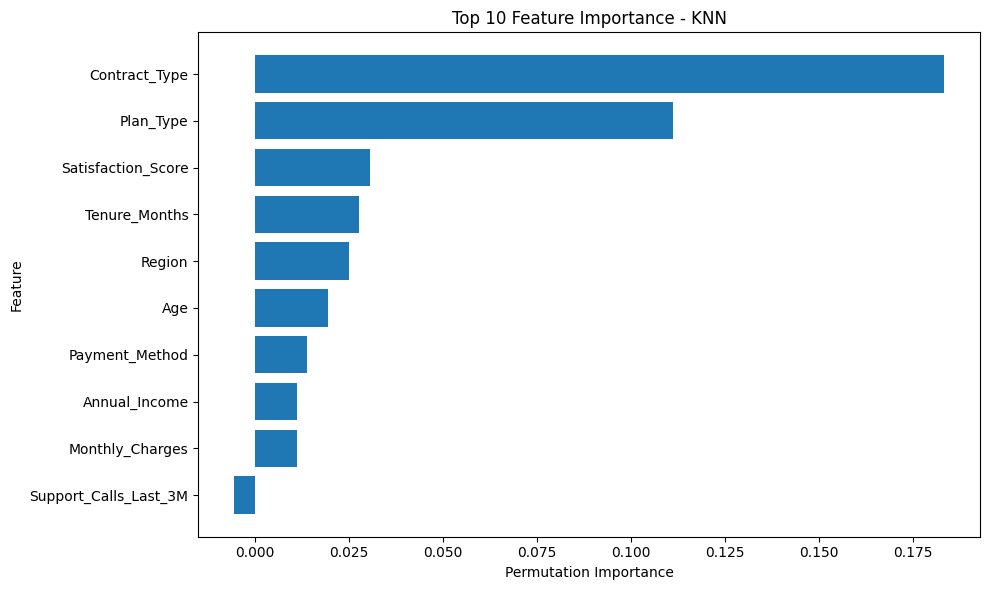

In [318]:
plt.figure(figsize=(10, 6))

top_features = importance_df.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - KNN")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [319]:
k_values = [3, 5, 7, 9, 11]

results = []

for k in k_values:

    knn_model = Pipeline(steps=[
        ('preprocessor', preprocessor_minmax),
        ('classifier', KNeighborsClassifier(
            n_neighbors=k
        ))
    ])
    knn_model.fit(X_train, y_train)
    y_pred = knn_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    cv_scores = cross_val_score(
        knn_model,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    results.append({
        'K': k,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'CV Score': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })

knn_results = pd.DataFrame(results)

print(knn_results)


    K  Accuracy  Precision    Recall  F1 Score  CV Score    CV Std
0   3  0.611111   0.666667  0.526316  0.588235  0.549507  0.094449
1   5  0.638889   0.714286  0.526316  0.606061  0.514286  0.076226
2   7  0.583333   0.642857  0.473684  0.545455  0.507389  0.083133
3   9  0.638889   0.687500  0.578947  0.628571  0.514286  0.093081
4  11  0.611111   0.666667  0.526316  0.588235  0.472414  0.065062


In [320]:
print("Target column:", target)

print("\nTarget statistics:")
print(y.describe())

print("\nTarget sample:")
print(y.head(10))

print("\nTarget dtype:")
print(y.dtype)

Target column: Monthly_Charges

Target statistics:
count    180.000000
mean       0.522222
std        0.500899
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: Churn, dtype: float64

Target sample:
0    1
1    1
2    1
3    1
4    1
5    0
6    0
7    0
8    0
9    1
Name: Churn, dtype: int64

Target dtype:
int64


In [321]:
print("y_test statistics:")
print(y_test.describe())

print("\nActual values:")
print(y_test.head(10))

y_test statistics:
count    36.000000
mean      0.527778
std       0.506309
min       0.000000
25%       0.000000
50%       1.000000
75%       1.000000
max       1.000000
Name: Churn, dtype: float64

Actual values:
180    1
15     1
69     1
174    0
118    0
61     1
152    0
160    0
50     0
163    1
Name: Churn, dtype: int64


In [322]:
print("Predicted values:")
print(y_pred[:10])

print("\nActual values:")
print(y_test.head(10).values)

Predicted values:
[0 1 0 0 0 0 1 1 0 0]

Actual values:
[1 1 1 0 0 1 0 0 0 1]


In [323]:
X = df.drop(columns=[target])
y = df[target]

In [324]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [325]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

In [326]:
print(df.columns.tolist())
print(target)
print(y.describe())
print(df.shape)

['Customer_ID', 'Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type', 'Churn']
Monthly_Charges
count    180.000000
mean      74.942889
std       25.580257
min        9.970000
25%       59.130000
50%       73.565000
75%       88.750000
max      151.180000
Name: Monthly_Charges, dtype: float64
(180, 13)


## Regression

In [327]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    BaggingRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [328]:
df = pd.read_csv("cleaned_customer.csv")

df.shape

(180, 13)

In [329]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(numeric_cols)

Numerical Columns:
Index(['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges',
       'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score'],
      dtype='object')


In [330]:
df.select_dtypes(include=['int64', 'float64']).columns.tolist()

['Age',
 'Annual_Income',
 'Tenure_Months',
 'Monthly_Charges',
 'Support_Calls_Last_3M',
 'Data_Usage_GB',
 'Satisfaction_Score']

Regression Target: Monthly_Charges


In [332]:
df[target].describe()

count    180.000000
mean      74.942889
std       25.580257
min        9.970000
25%       59.130000
50%       73.565000
75%       88.750000
max      151.180000
Name: Monthly_Charges, dtype: float64

In [333]:
df[target].isnull().sum()

np.int64(0)

In [334]:
model_df = df.copy()

model_df = model_df.drop(columns=['Customer_ID'])

X = model_df.drop(columns=[target])
y = model_df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (180, 11)
y shape: (180,)


In [335]:
X.head()

,Age,Annual_Income,Tenure_Months,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,22.0,23800.0,11.0,7.0,20.4,5.0,Monthly,Bank Transfer,North,Standard,Yes
1,35.0,69400.0,17.0,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,55.0,64700.0,49.0,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,36.0,80000.0,9.0,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,41.0,95700.0,51.0,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes


In [336]:
y.head()

0    62.96
1    75.63
2    92.85
3    85.67
4    60.77
Name: Monthly_Charges, dtype: float64

In [337]:
numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

Numerical Features:
['Age', 'Annual_Income', 'Tenure_Months', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score']


In [338]:
categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

Categorical Features:
['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type', 'Churn']


In [339]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (144, 11)
X_test : (36, 11)
y_train: (144,)
y_test : (36,)


In [340]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [341]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [342]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [343]:
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [344]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Annual_Income',
                                                   'Tenure_Months',
                                                   'Support_Calls_Last_3M',
                                                   'Data_Usage_GB',
                                                   'Satisfaction_Score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Contract_Type',
                                                   'Payment_Method', 'Region',
                                                   'Plan_Type', 'Churn'])])),
                ('regressor', LinearRegression())])

In [345]:
y_pred_linear = linear_model.predict(X_test)
y_pred_linear[:10]

array([78.79082112, 90.37553333, 68.72787084, 85.34666287, 63.67446109,
       68.16632487, 57.53249643, 75.86911309, 58.5991174 , 55.37685223])

In [346]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)

mse_linear = mean_squared_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(mse_linear)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("--------------------------")
print("MAE  :", mae_linear)
print("MSE  :", mse_linear)
print("RMSE :", rmse_linear)
print("R²   :", r2_linear)

Linear Regression
--------------------------
MAE  : 30.13568229079351
MSE  : 1332.8202637978263
RMSE : 36.507810997070564
R²   : -0.4248470808854208


In [347]:
decision_tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(
        random_state=42
    ))
])

In [348]:
decision_tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Annual_Income',
                                                   'Tenure_Months',
                                                   'Support_Calls_Last_3M',
                                                   'Data_Usage_GB',
                                                   'Satisfaction_Score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Contract_Type',
                                                   'Payment_Method', 'Region',
                                                   'Plan_Type', 'Churn'])])),
                ('regressor', DecisionTreeRegressor(random_state=42))])

In [349]:
y_pred_dt = decision_tree_model.predict(X_test)

In [350]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)

mse_dt = mean_squared_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(mse_dt)

r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regression")
print("--------------------------")
print("MAE  :", mae_dt)
print("MSE  :", mse_dt)
print("RMSE :", rmse_dt)
print("R²   :", r2_dt)

Decision Tree Regression
--------------------------
MAE  : 35.50347222222222
MSE  : 1684.3327604166666
RMSE : 41.040623294690185
R²   : -0.8006303491221605


In [351]:
random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

In [352]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Annual_Income',
                                                   'Tenure_Months',
                                                   'Support_Calls_Last_3M',
                                                   'Data_Usage_GB',
                                                   'Satisfaction_Score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Contract_Type',
                                                   'Payment_Method', 'Region',
                                                   'Plan_Type', 'Churn'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [353]:
y_pred_rf = random_forest_model.predict(X_test)

In [354]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression")
print("--------------------------")
print("MAE  :", mae_rf)
print("MSE  :", mse_rf)
print("RMSE :", rmse_rf)
print("R²   :", r2_rf)

Random Forest Regression
--------------------------
MAE  : 29.134758333333327
MSE  : 1254.1024472961103
RMSE : 35.41330890069594
R²   : -0.34069406032993665


In [355]:
bagging_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=100,
        random_state=42
    ))
])

In [356]:
bagging_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=100,
        random_state=42
    ))
])

In [357]:
bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)

In [358]:
mae_bagging = mean_absolute_error(
    y_test,
    y_pred_bagging
)

mse_bagging = mean_squared_error(
    y_test,
    y_pred_bagging
)

rmse_bagging = np.sqrt(mse_bagging)

r2_bagging = r2_score(
    y_test,
    y_pred_bagging
)

print("Bagging Regression")
print("--------------------------")
print("MAE  :", mae_bagging)
print("MSE  :", mse_bagging)
print("RMSE :", rmse_bagging)
print("R²   :", r2_bagging)

Bagging Regression
--------------------------
MAE  : 29.07204027777778
MSE  : 1258.285607225486
RMSE : 35.47232170616248
R²   : -0.3451660535732446


In [359]:
boosting_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ))
])

In [360]:
boosting_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Annual_Income',
                                                   'Tenure_Months',
                                                   'Support_Calls_Last_3M',
                                                   'Data_Usage_GB',
                                                   'Satisfaction_Score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Contract_Type',
                                                   'Payment_Method', 'Region',
                                                   'Plan_Type', 'Churn'])])),
                ('regressor', GradientBoostingRegressor(random_state=42))])

In [361]:
y_pred_boosting = boosting_model.predict(X_test)

In [362]:
mae_boosting = mean_absolute_error(
    y_test,
    y_pred_boosting
)

mse_boosting = mean_squared_error(
    y_test,
    y_pred_boosting
)

rmse_boosting = np.sqrt(mse_boosting)

r2_boosting = r2_score(
    y_test,
    y_pred_boosting
)

print("Gradient Boosting Regression")
print("--------------------------")
print("MAE  :", mae_boosting)
print("MSE  :", mse_boosting)
print("RMSE :", rmse_boosting)
print("R²   :", r2_boosting)

Gradient Boosting Regression
--------------------------
MAE  : 28.52268612949214
MSE  : 1217.3499863723548
RMSE : 34.89054293605009
R²   : -0.30140396391937374


In [363]:
results = [
    {
        "Model": "Linear Regression",
        "MAE": mae_linear,
        "MSE": mse_linear,
        "RMSE": rmse_linear,
        "R2": r2_linear
    },
    {
        "Model": "Decision Tree",
        "MAE": mae_dt,
        "MSE": mse_dt,
        "RMSE": rmse_dt,
        "R2": r2_dt
    },
    {
        "Model": "Random Forest",
        "MAE": mae_rf,
        "MSE": mse_rf,
        "RMSE": rmse_rf,
        "R2": r2_rf
    },
    {
        "Model": "Bagging",
        "MAE": mae_bagging,
        "MSE": mse_bagging,
        "RMSE": rmse_bagging,
        "R2": r2_bagging
    },
    {
        "Model": "Gradient Boosting",
        "MAE": mae_boosting,
        "MSE": mse_boosting,
        "RMSE": rmse_boosting,
        "R2": r2_boosting
    }
]

regression_results = pd.DataFrame(results)

regression_results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,30.135682,1332.820264,36.507811,-0.424847
1,Decision Tree,35.503472,1684.332760,41.040623,-0.800630
2,Random Forest,29.134758,1254.102447,35.413309,-0.340694
3,Bagging,29.072040,1258.285607,35.472322,-0.345166
4,Gradient Boosting,28.522686,1217.349986,34.890543,-0.301404


In [364]:
regression_results.sort_values(
    by='R2',
    ascending=False
)

,Model,MAE,MSE,RMSE,R2
4,Gradient Boosting,28.522686,1217.349986,34.890543,-0.301404
2,Random Forest,29.134758,1254.102447,35.413309,-0.340694
3,Bagging,29.072040,1258.285607,35.472322,-0.345166
0,Linear Regression,30.135682,1332.820264,36.507811,-0.424847
1,Decision Tree,35.503472,1684.332760,41.040623,-0.800630


In [365]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# Numerical columns
numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# Categorical columns
categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Numerical columns:", numeric_features)
print("Categorical columns:", categorical_features)
print("MinMaxScaler preprocessing is ready!")

Numerical columns: ['Age', 'Annual_Income', 'Tenure_Months', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score']
Categorical columns: ['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type', 'Churn']
MinMaxScaler preprocessing is ready!


In [366]:
# ============================================================
# REGRESSION ALGORITHMS WITH MINMAX SCALER
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# Regression Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    BaggingRegressor,
    GradientBoostingRegressor
)

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 1. SELECT TARGET
# ============================================================

target = 'Monthly_Charges'   # Change this to your regression target

X = df.drop(columns=[target])
y = df[target]


# ============================================================
# 2. IDENTIFY NUMERICAL & CATEGORICAL COLUMNS
# ============================================================

numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()


# ============================================================
# 3. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 4. MINMAX SCALER PREPROCESSING
# ============================================================

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


# ============================================================
# 5. DEFINE ALL REGRESSION ALGORITHMS
# ============================================================

models = {

    'Linear Regression': LinearRegression(),

    'Decision Tree Regression': DecisionTreeRegressor(
        random_state=42
    ),

    'Random Forest Regression': RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    'Bagging Regression': BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=100,
        random_state=42
    ),

    'Gradient Boosting Regression': GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )
}


# ============================================================
# 6. TRAIN + PREDICT + EVALUATE ALL MODELS
# ============================================================

results = []

trained_models = {}

for name, model in models.items():

    # Create pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Prediction
    y_pred = pipeline.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Store model
    trained_models[name] = pipeline

    # Store results
    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })


# ============================================================
# 7. FINAL RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='R2 Score',
    ascending=False
).reset_index(drop=True)

print("REGRESSION MODEL COMPARISON")
print("=" * 70)

display(results_df)

REGRESSION MODEL COMPARISON


,Model,MAE,MSE,RMSE,R2 Score
0,Bagging Regression,28.057290,1151.293049,33.930710,-0.230786
1,Random Forest Regression,28.163771,1174.378407,34.269205,-0.255465
2,Gradient Boosting Regression,27.551283,1174.567347,34.271962,-0.255667
3,Linear Regression,29.789696,1306.440203,36.144712,-0.396646
4,Decision Tree Regression,31.782639,1345.534663,36.681530,-0.438439
